<a href="https://colab.research.google.com/github/SubodhWalondre-1/Machine-Vision-Lab/blob/main/Prac_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload Reference Road Sign Image


Saving 4.jpg to 4 (1).jpg
Upload Test Road Scene Image


Saving 5.jpg to 5.jpg
Reference Keypoints : 524
Test Keypoints      : 1000
Good Matches : 50


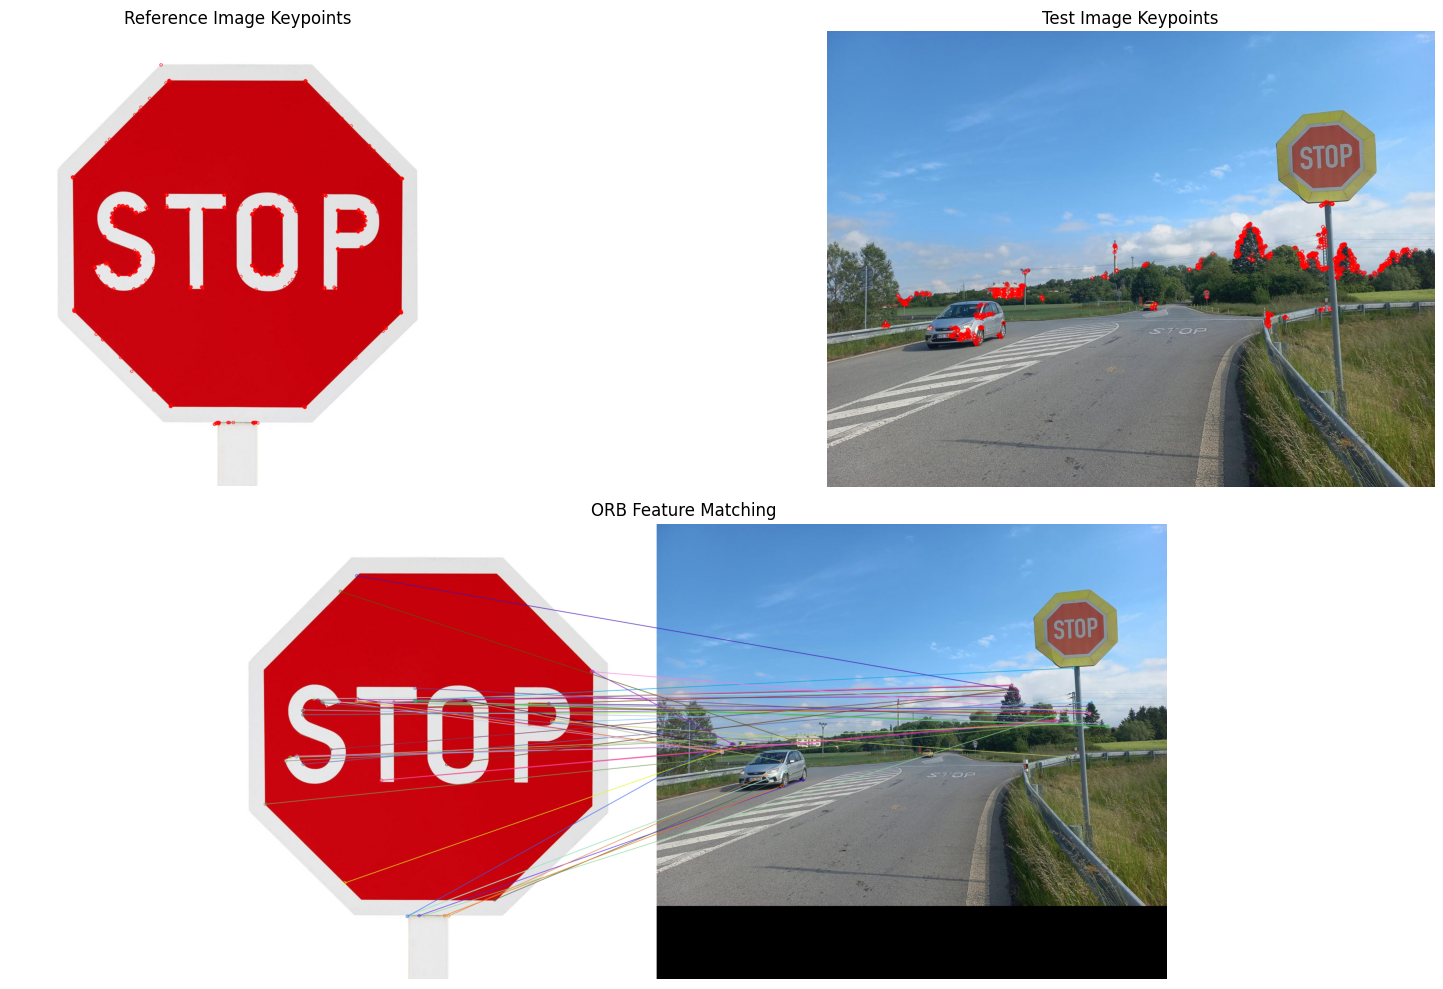


Road Sign Identified Successfully


In [2]:
# ==========================================================
# ROAD SIGN RECOGNITION USING ORB + FAST + BRIEF
# Google Colab
# ==========================================================

# Install OpenCV
!pip -q install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================================================
# Upload Reference Image
# ==========================================================

print("Upload Reference Road Sign Image")
ref_upload = files.upload()
ref_path = list(ref_upload.keys())[0]

# ==========================================================
# Upload Test Image
# ==========================================================

print("Upload Test Road Scene Image")
test_upload = files.upload()
test_path = list(test_upload.keys())[0]

# ==========================================================
# Read Images
# ==========================================================

img1 = cv2.imread(ref_path)
img2 = cv2.imread(test_path)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

rgb1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
rgb2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# ==========================================================
# ORB Feature Detector
# (Uses FAST + BRIEF internally)
# ==========================================================

orb = cv2.ORB_create(nfeatures=1000)

kp1, des1 = orb.detectAndCompute(gray1,None)
kp2, des2 = orb.detectAndCompute(gray2,None)

print("Reference Keypoints :", len(kp1))
print("Test Keypoints      :", len(kp2))

# ==========================================================
# Feature Matching
# ==========================================================

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1,des2)

matches = sorted(matches,key=lambda x:x.distance)

good_matches = matches[:50]

print("Good Matches :", len(good_matches))

# ==========================================================
# Draw Matches
# ==========================================================

matched = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches,
    None,
    flags=2
)

matched = cv2.cvtColor(matched,cv2.COLOR_BGR2RGB)

# ==========================================================
# Draw Keypoints
# ==========================================================

ref_key = cv2.drawKeypoints(
    rgb1,
    kp1,
    None,
    color=(255,0,0)
)

test_key = cv2.drawKeypoints(
    rgb2,
    kp2,
    None,
    color=(255,0,0)
)

# ==========================================================
# Display Results
# ==========================================================

plt.figure(figsize=(18,10))

plt.subplot(2,2,1)
plt.imshow(ref_key)
plt.title("Reference Image Keypoints")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(test_key)
plt.title("Test Image Keypoints")
plt.axis("off")

plt.subplot(2,1,2)
plt.imshow(matched)
plt.title("ORB Feature Matching")
plt.axis("off")

plt.tight_layout()
plt.show()

# ==========================================================
# Recognition Result
# ==========================================================

if len(good_matches) > 20:
    print("\nRoad Sign Identified Successfully")
else:
    print("\nRoad Sign Not Matched")